In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt

from svm import SVM

In [3]:
def zipper_2D_dataset(n_pos, n_neg, scope=4.0, device='cpu'):
    torch.manual_seed(32)
    halfs = scope / 2
  
    limit = halfs * torch.pi
    
    x1_pos = torch.rand(n_pos, device=device) * (2 * limit) - limit
    x2_pos = torch.sin(x1_pos) + 0.5
    
    x1_neg = torch.rand(n_neg, device=device) * (2 * limit) - limit
    x2_neg = torch.sin(x1_neg) - 0.5
    
    noise_strength = 0.1
    x2_pos += torch.randn(n_pos, device=device) * noise_strength
    x2_neg += torch.randn(n_neg, device=device) * noise_strength
  
    x_pos = torch.stack([x1_pos, x2_pos], dim=1)  
    x_neg = torch.stack([x1_neg, x2_neg], dim=1) 
    
    x = torch.cat([x_pos, x_neg], dim=0)        
    y = torch.cat([torch.ones(n_pos, device=device), 
                   -torch.ones(n_neg, device=device)])
    
    return x, y

x_train, y_train = zipper_2D_dataset(100, 100, scope=4.0)
x_test, y_test = zipper_2D_dataset(50, 50, scope=5.5) # test data is slightly out-of-distribution

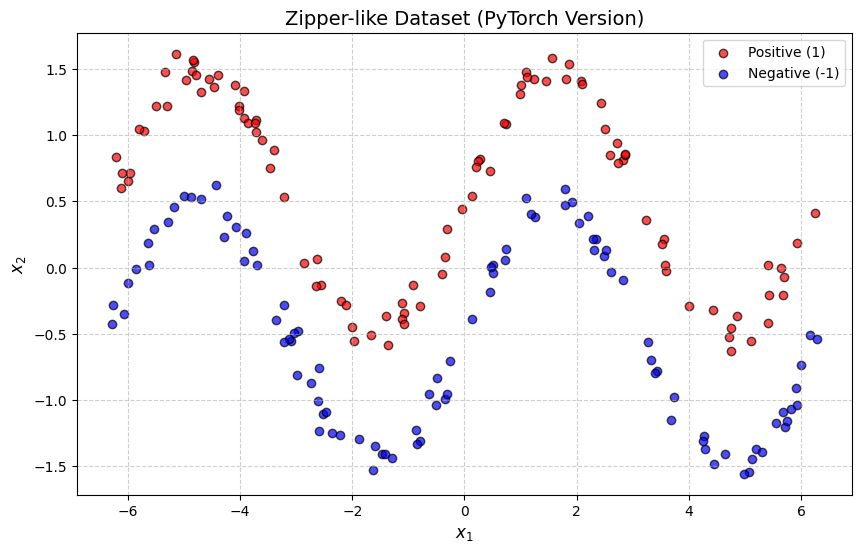

In [4]:
def visualize_2D_dataset(x, y):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()

    assert x.shape[1] == 2, "x must be 2D for visualization."

    plt.figure(figsize=(10, 6))

    x_pos = x[y == 1]
    x_neg = x[y == -1]

    plt.scatter(x_pos[:, 0], x_pos[:, 1], c='red', label='Positive (1)', alpha=0.7, edgecolors='k')
    plt.scatter(x_neg[:, 0], x_neg[:, 1], c='blue', label='Negative (-1)', alpha=0.7, edgecolors='k')

    plt.title('Zipper-like Dataset (PyTorch Version)', fontsize=14)
    plt.xlabel('$x_1$', fontsize=12)
    plt.ylabel('$x_2$', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

visualize_2D_dataset(x_train, y_train)

# 

In [ ]:
svm=SVM()


# 